<a href="https://colab.research.google.com/github/naomiescobar/CSC398-data/blob/main/csc398_hwk7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 7 (in-class)

### Instructions
Work in small groups (2 or 3).  You are encouraged to use AI tools to develop your solutions.  Be prepared to present your work at the end of class.  

### Assignment Submssion
After you complete the exercises below, click on the Share button (in the top right corner) and change the "General access" option to "Anyone with the link".  Submit the link to your Colab Notebook in Teams (all group members must make a submission to receive credit).  

### Install nba_api module

In [1]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 6.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import leagueleaders
import json

# Part I: Extract game data from nba_api

Request data for 2023-24, limiting results to regular season games
(not playoffs or All-Star).  Players are ranked by points.  


In [3]:
season = "2023-24"

leaders = leagueleaders.LeagueLeaders(
    season = season,
    season_type_all_star = "Regular Season",
    per_mode48 = "Totals", # Legacy parameter name
    stat_category_abbreviation = "PTS"
)

# Convert results to dictionary
raw_data = leaders.get_dict()

# Show the main sections of the response (resource,
# parameters, resultSets) before accessing specific values.
raw_data.keys()





dict_keys(['resource', 'parameters', 'resultSet'])

In [4]:
# Shows the keys inside the resultSet dictionary (name, headers, rowSet)
print(raw_data["resultSet"].keys())

dict_keys(['name', 'headers', 'rowSet'])


In [5]:
# Show stats stored about players
print(raw_data["resultSet"]["headers"])

['PLAYER_ID', 'RANK', 'PLAYER', 'TEAM_ID', 'TEAM', 'GP', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'EFF', 'AST_TOV', 'STL_TOV']


In [12]:
# Access the first row inside the rowSet list (index 0)
# to inspect a single player’s stats.
print(raw_data["resultSet"]["rowSet"][0])

[1629029, 1, 'Luka Dončić', 1610612742, 'DAL', 70, 2624, 804, 1652, 0.487, 284, 744, 0.382, 478, 608, 0.786, 59, 588, 647, 686, 99, 38, 282, 149, 2370, 2580, 2.43, 0.35]


### Extract data as a DataFrame

In [7]:
# Convert the API response into a pandas DataFrame (a structured table).
# The API can return multiple "tables". [0] selects the first (and main) one.
df = leaders.get_data_frames()[0]

# Display the top 5 rows of the table to view the top scorers.
print(df.head(10))

# Inspect the available fields before selecting, filtering, or plotting data.
print(df.columns)

   PLAYER_ID  RANK                   PLAYER     TEAM_ID TEAM  GP   MIN  FGM  \
0    1629029     1              Luka Dončić  1610612742  DAL  70  2624  804   
1    1628983     2  Shai Gilgeous-Alexander  1610612760  OKC  75  2553  796   
2     203507     3    Giannis Antetokounmpo  1610612749  MIL  73  2567  837   
3    1628973     4            Jalen Brunson  1610612752  NYK  77  2726  790   
4     203999     5             Nikola Jokić  1610612743  DEN  79  2737  822   
5    1630162     6          Anthony Edwards  1610612750  MIN  79  2770  718   
6     201142     7             Kevin Durant  1610612756  PHX  75  2791  751   
7    1628369     8             Jayson Tatum  1610612738  BOS  74  2645  672   
8    1628368     9             De'Aaron Fox  1610612758  SAC  74  2659  720   
9     201939    10            Stephen Curry  1610612744  GSW  74  2422  650   

    FGA  FG_PCT  ...  REB  AST  STL  BLK  TOV   PF   PTS   EFF  AST_TOV  \
0  1652   0.487  ...  647  686   99   38  282  149  237

### Home vs. Away Player Performance

In [8]:
from nba_api.stats.endpoints import playergamelog

player_id = 201939  # Stephen Curry
season = "2023-24"

# Get game log
gamelog = playergamelog.PlayerGameLog(
    player_id=player_id,
    season=season
)

df = gamelog.get_data_frames()[0]
df

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22023,201939,0022301182,"Apr 12, 2024",GSW vs. NOP,L,32,12,23,0.522,...,4,4,5,1,0,7,2,33,-8,1
1,22023,201939,0022301169,"Apr 11, 2024",GSW @ POR,W,36,8,22,0.364,...,7,7,8,1,2,2,0,22,7,1
2,22023,201939,0022301155,"Apr 09, 2024",GSW @ LAL,W,32,7,9,0.778,...,7,7,8,1,2,1,2,23,13,1
3,22023,201939,0022301097,"Apr 05, 2024",GSW @ DAL,L,35,9,23,0.391,...,5,6,5,1,0,2,2,28,-5,1
4,22023,201939,0022301113,"Apr 04, 2024",GSW @ HOU,W,31,9,14,0.643,...,6,6,6,0,0,3,2,29,29,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,22023,201939,0022300126,"Nov 01, 2023",GSW vs. SAC,W,32,7,15,0.467,...,4,5,3,0,0,7,3,21,-6,1
70,22023,201939,0022300108,"Oct 30, 2023",GSW @ NOP,W,30,15,22,0.682,...,5,5,5,2,0,3,1,42,13,1
71,22023,201939,0022300096,"Oct 29, 2023",GSW @ HOU,W,31,6,16,0.375,...,6,7,6,0,1,1,1,24,-2,1
72,22023,201939,0022300087,"Oct 27, 2023",GSW @ SAC,W,35,14,19,0.737,...,3,4,4,2,0,4,0,41,10,1


In [9]:

# Identify home vs away games

# MATCHUP examples:
# "GSW vs. LAL" = home
# "GSW @ LAL"  = away

df["LOCATION"] = df["MATCHUP"].apply(
    lambda x: "Home" if "vs." in x else "Away"
)
df

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,LOCATION
0,22023,201939,0022301182,"Apr 12, 2024",GSW vs. NOP,L,32,12,23,0.522,...,4,5,1,0,7,2,33,-8,1,Home
1,22023,201939,0022301169,"Apr 11, 2024",GSW @ POR,W,36,8,22,0.364,...,7,8,1,2,2,0,22,7,1,Away
2,22023,201939,0022301155,"Apr 09, 2024",GSW @ LAL,W,32,7,9,0.778,...,7,8,1,2,1,2,23,13,1,Away
3,22023,201939,0022301097,"Apr 05, 2024",GSW @ DAL,L,35,9,23,0.391,...,6,5,1,0,2,2,28,-5,1,Away
4,22023,201939,0022301113,"Apr 04, 2024",GSW @ HOU,W,31,9,14,0.643,...,6,6,0,0,3,2,29,29,1,Away
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,22023,201939,0022300126,"Nov 01, 2023",GSW vs. SAC,W,32,7,15,0.467,...,5,3,0,0,7,3,21,-6,1,Home
70,22023,201939,0022300108,"Oct 30, 2023",GSW @ NOP,W,30,15,22,0.682,...,5,5,2,0,3,1,42,13,1,Away
71,22023,201939,0022300096,"Oct 29, 2023",GSW @ HOU,W,31,6,16,0.375,...,7,6,0,1,1,1,24,-2,1,Away
72,22023,201939,0022300087,"Oct 27, 2023",GSW @ SAC,W,35,14,19,0.737,...,4,4,2,0,4,0,41,10,1,Away


In [10]:
# Compute averages
avg_pts = df.groupby("LOCATION")["PTS"].mean()

print("\nAverage Points Per Game")
print(avg_pts)




Average Points Per Game
LOCATION
Away    25.657895
Home    27.250000
Name: PTS, dtype: float64


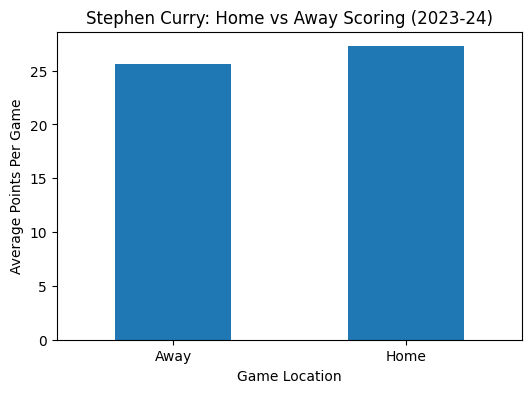

In [11]:

# Plot comparison

plt.figure(figsize=(6,4))

avg_pts.plot(
    kind="bar",
)

plt.title("Stephen Curry: Home vs Away Scoring (2023-24)")
plt.ylabel("Average Points Per Game")
plt.xlabel("Game Location")
plt.xticks(rotation=0)

plt.show()

# Part II: Exercises


---



### TEAM MEMBERS

Alison Escobar :)



---



## Exercise 1: Efficiency vs. Volume

### A. For the 2023 - 2024 season, identify the 10 players with the highest field goal percentage (FG_PCT), field goal percentage on three-point shots (FG3_PCT), and free throw percentage (FT_PCT).  **Insert your code in the cell below**.


In [23]:
from nba_api.stats.endpoints import leagueleaders

leaders = leagueleaders.LeagueLeaders(
    season="2023-24",
    season_type_all_star="Regular Season",
    per_mode48="Totals",
    stat_category_abbreviation="PTS"
)

df = leaders.get_data_frames()[0]

In [24]:
# Top 10 by FG%
top_fg = df.sort_values(by="FG_PCT", ascending=False).head(10)[["PLAYER", "FG_PCT"]]
print("Top 10 FG%")
print(top_fg)

# Top 10 by 3PT%
top_fg3 = df.sort_values(by="FG3_PCT", ascending=False).head(10)[["PLAYER", "FG3_PCT"]]
print("\nTop 10 3PT%")
print(top_fg3)

# Top 10 by FT%
top_ft = df.sort_values(by="FT_PCT", ascending=False).head(10)[["PLAYER", "FT_PCT"]]
print("\nTop 10 FT%")
print(top_ft)

Top 10 FG%
                   PLAYER  FG_PCT
228      Dereck Lively II   0.747
138        Daniel Gafford   0.725
436        Charles Bassey   0.725
286          Jaxson Hayes   0.720
202  Trayce Jackson-Davis   0.702
274           Luke Kornet   0.700
472        Udoka Azubuike   0.696
412          Jericho Sims   0.691
172         Nick Richards   0.691
470        Marques Bolden   0.680

Top 10 3PT%
               PLAYER  FG3_PCT
534       D.J. Wilson    1.000
554        Pete Nance    1.000
255      Drew Eubanks    1.000
274       Luke Kornet    1.000
456      Ryan Rollins    0.750
527       Jordan Ford    0.667
530     Drew Peterson    0.600
406  Orlando Robinson    0.533
520    Dereon Seabron    0.500
524     Jordan Miller    0.500

Top 10 FT%
                PLAYER  FT_PCT
560    Quenton Jackson     1.0
544   Alondes Williams     1.0
543  Lindell Wigginton     1.0
538      James Johnson     1.0
527        Jordan Ford     1.0
510        Robin Lopez     1.0
515         Alex Fudge     1.0
5

### B. Why might a player score a lot but not be the most efficient? What role does shot volume play? **Provide your answer in the cell below.**


Players can put up big point totals even if they aren’t very efficient, simply because they take a lot of shots. Efficiency reflects how well a player converts their attempts, while total scoring is driven by how many shots they take. Someone with a high shot volume might miss more often but still end up with more points overall. On the other hand, a very efficient player who takes fewer shots may score less in total.

### C. Create a scatter plot that shows total points scored vs field goal percentage. Filter total points scored to only show values above 300.


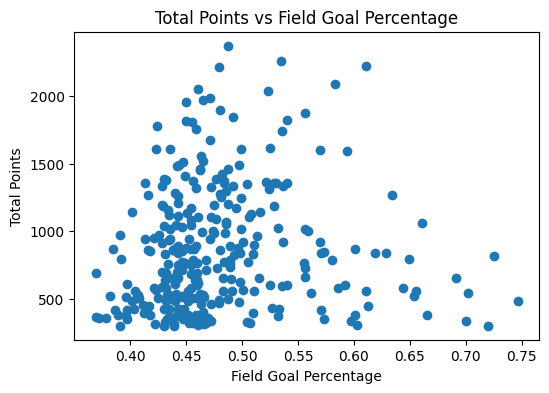

In [25]:
filtered_df = df[df["PTS"] > 300]

plt.figure(figsize=(6,4))
plt.scatter(filtered_df["FG_PCT"], filtered_df["PTS"])

plt.title("Total Points vs Field Goal Percentage")
plt.xlabel("Field Goal Percentage")
plt.ylabel("Total Points")

plt.show()

### D. What observations can we make based on the visualization?  Identify at least 3 observations.


1.  There is no strong linear relationship between field goal percentage and total points, as players with similar FG% can have very different point totals.
2.  Most players cluster between 0.43 and 0.55 FG%, showing that many scorers fall within a similar efficiency range.
3.  Players with the highest point totals are not necessarily the most efficient, suggesting that shot volume plays a major role in scoring.
4.  Some players with very high FG% (above 0.60) have relatively low total points, likely because they take fewer shots.



---



## Exercise 2

### A. Next, we’ll explore how total points scored (PTS) relates to opportunity: games played (GP) and minutes played (MIN).

Pull the following columns for the top 10 scorers:
PLAYER, TEAM, PTS, GP, MIN

Create a scatter plot that shows total points scored vs minutes played. Label each data point with the player’s name.



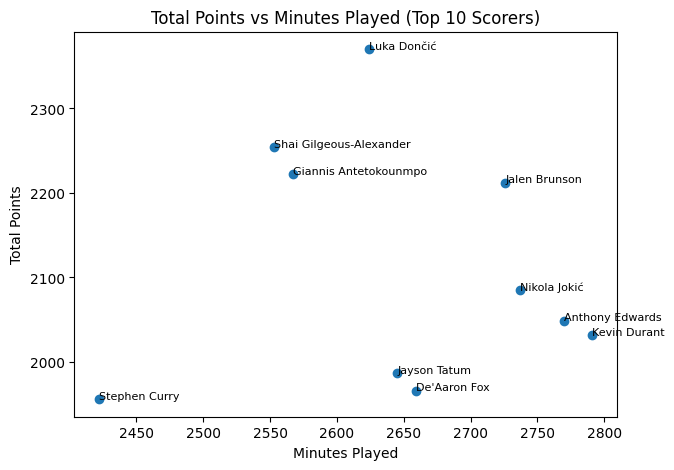

In [26]:
top10 = df.head(10)[["PLAYER", "TEAM", "PTS", "GP", "MIN"]]

plt.figure(figsize=(7,5))
plt.scatter(top10["MIN"], top10["PTS"])

for i, row in top10.iterrows():
    plt.text(row["MIN"], row["PTS"], row["PLAYER"], fontsize=8)

plt.title("Total Points vs Minutes Played (Top 10 Scorers)")
plt.xlabel("Minutes Played")
plt.ylabel("Total Points")

plt.show()

### B. What are a few conclusions we can draw from this scatter plot?


There is a strong positive relationship between minutes played and total points scored. For example, players like Luka Dončić and Jalen Brunson have both high minutes and high point totals. However, the relationship is not perfectly linear, since some players with similar minutes have different scoring totals. This suggests that efficiency and scoring ability also play a role. For instance, Stephen Curry has fewer minutes but still maintains a relatively high scoring output. Overall, minutes played strongly influence scoring, but individual performance and efficiency also impact total points.

## Exercise 3

### A. Consider the home vs. away analysis above.  Rerun the analysis for a different player of your choice using a different metric (e.g. rebounds, assists, etc.).  Show the averages for this metric (home vs. away) and bar plot.

LOCATION
Away    7.718750
Home    8.769231
Name: AST, dtype: float64


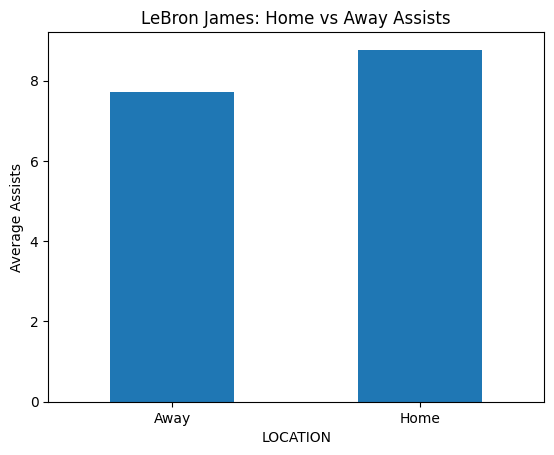

In [27]:
from nba_api.stats.endpoints import playergamelog

player_id = 2544  # LeBron James
season = "2023-24"

gamelog = playergamelog.PlayerGameLog(
    player_id=player_id,
    season=season
)

df_player = gamelog.get_data_frames()[0]

# Home vs Away
df_player["LOCATION"] = df_player["MATCHUP"].apply(
    lambda x: "Home" if "vs." in x else "Away"
)

# Use assists instead of points
avg_ast = df_player.groupby("LOCATION")["AST"].mean()

print(avg_ast)

# Plot
avg_ast.plot(kind="bar")
plt.title("LeBron James: Home vs Away Assists")
plt.ylabel("Average Assists")
plt.xticks(rotation=0)
plt.show()

### B. Compute the average for home and away games for 10 players of your choice.  Generate a scatter plot of these averages (home on the x-axis, and away on the y-axis).  Label each points with the player names.    

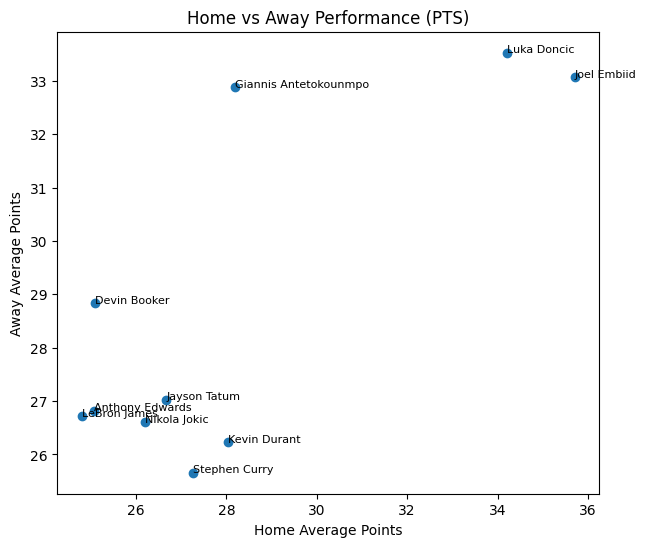

In [30]:
players = {
    "Stephen Curry": 201939,
    "LeBron James": 2544,
    "Kevin Durant": 201142,
    "Giannis Antetokounmpo": 203507,
    "Jayson Tatum": 1628369,
    "Nikola Jokic": 203999,
    "Luka Doncic": 1629029,
    "Anthony Edwards": 1630162,
    "Devin Booker": 1626164,
    "Joel Embiid": 203954
}

home_avg = []
away_avg = []
names = []

for name, pid in players.items():
    gamelog = playergamelog.PlayerGameLog(player_id=pid, season="2023-24")
    temp = gamelog.get_data_frames()[0]

    temp["LOCATION"] = temp["MATCHUP"].apply(
        lambda x: "Home" if "vs." in x else "Away"
    )

    avg = temp.groupby("LOCATION")["PTS"].mean()

    if "Home" in avg and "Away" in avg:
        home_avg.append(avg["Home"])
        away_avg.append(avg["Away"])
        names.append(name)

plt.figure(figsize=(7,6))
plt.scatter(home_avg, away_avg)

for i in range(len(names)):
    plt.text(home_avg[i], away_avg[i], names[i], fontsize=8)

plt.xlabel("Home Average Points")
plt.ylabel("Away Average Points")
plt.title("Home vs Away Performance (PTS)")

plt.show()

## Reflections on the use of AI Tools

### A. What prompts did you give the AI tool? Include at least one example prompt. How did you revise or refine your prompts during the process?  If you didn't use AI tools, state so.


One prompt I used was: “Write Python code using nba_api to create a scatter plot of points vs field goal percentage with filtering.” I refined my prompts by adding more details, such as specifying columns, adding labels, and filtering data above a certain threshold. At first, the responses were too general, so I made them more specific to match the assignment requirements.

### B. Did the AI produce any incorrect or misleading output? If so, describe what went wrong and how you fixed it. How did you verify that the AI-generated output was correct?


The AI initially produced an error because it used the wrong dataframe, which caused a KeyError when trying to access certain columns. I fixed this by recreating the correct dataframe and checking the column names using df.columns. I verified the results by making sure the plots and outputs matched the dataset and made logical sense.


###   